## SMOTE(Synthetic Minority Oversampling Technique)
SMOTE (Synthetic Minority Over-sampling Technique) is a technique used in machine learning to address imbalanced datasets where the minority class has significantly fewer instances than the majority class. SMOTE involves generating synthetic instances of the minority class by interpolating between existing instances.

In [ ]:
from sklearn.datasets import make_classification
## make_classification() generates synthetic classification data with customizable features, class distribution, and cluster structure.

In [ ]:
X,y=make_classification(n_samples=1000,n_redundant=0,n_features=2,n_clusters_per_class=1,
                   weights=[0.90],random_state=12)
## weights -> Controls class imbalance(90% sample belong to class 0 and 10% to class 1)
## n_redundant => Number of repeated features(Redundant features are: Features created from combination of other features. Since 0 all features are independent)
## Height (m) = Height (cm) / 100 , So "Height (m)" is redundant feature because it is derived from another feature.

In [3]:
import pandas as pd
df1=pd.DataFrame(X,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
final_df=pd.concat([df1,df2],axis=1)
final_df.head()

,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [4]:
final_df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

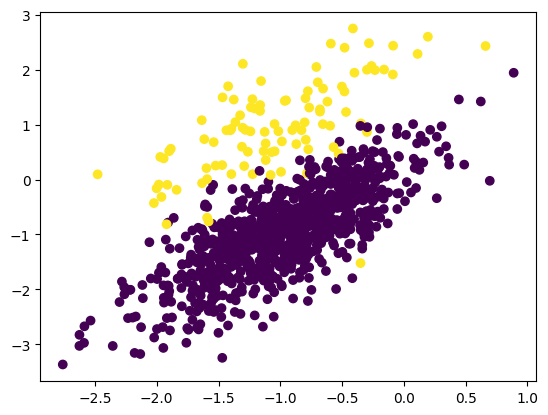

In [5]:
import matplotlib.pyplot as plt
plt.scatter(final_df['f1'],final_df['f2'],c=final_df['target'])
## c stands for color, It assigns different colors to points based on target values.

In [6]:
## To implement SMOTE, we require this library from python3
%pip install imblearn


   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   -------------------------- ------------- 2/3 [imblearn]
   ---------------------------------------- 3/3 [imblearn]

Note: you may need to restart the kernel to use updated packages.


In [7]:
from imblearn.over_sampling import SMOTE

In [ ]:
## transform the dataset
## SMOTE balances dataset ,Creates new synthetic minority class samples, Prevents duplication problem of normal upsampling
oversample=SMOTE() ## Creates SMOTE object 
X,y=oversample.fit_resample(final_df[['f1','f2']],final_df['target']) ## identifies minority class points and Generates new synthetic minority samples

In [9]:
X.shape

(1800, 2)

In [10]:
y.shape

(1800,)

In [18]:
len(y[y==0])

900

In [11]:
len(y[y==1])

900

In [ ]:
df1=pd.DataFrame(X,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
oversample_df=pd.concat([df1,df2],axis=1)
##axis=1 → Join columns horizontally, axis=0 → Join rows vertically

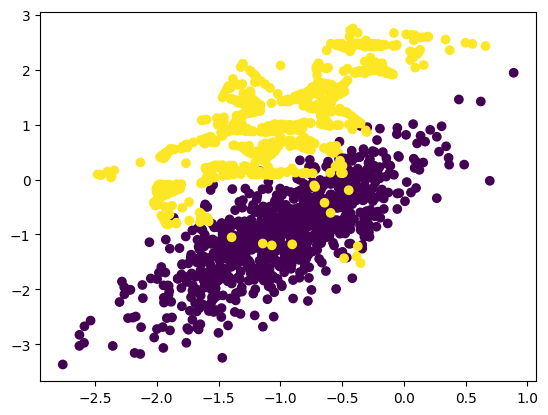

In [ ]:
plt.scatter(oversample_df['f1'],oversample_df['f2'],c=oversample_df['target'])
## c stands for color, It assigns different colors to points based on target values.